# Demonstrating the Limitations of ComBat and general location-scale models

## Overview

ComBat is a widely used harmonization method that removes scanner or site effects using a **location–scale model with empirical Bayes estimation**. In its standard formulation, ComBat assumes that scanner-related variability can be decomposed into additive (mean-shifting) and multiplicative (variance-scaling) effects applied to each feature. This approach relies on several key assumptions, among which we focus on:

- **linear covariate effects**  
- **additive and multiplicative (location–scale) scanner effects**  
- **discrete scanner/site grouping**  

While these assumptions lead to a tractable and effective model in many settings, they impose a restrictive structure on the data-generating process that may not hold in realistic neuroimaging applications.

---

## Strategy

To assess these limitations in a controlled setting, we use simulated data with known ground truth. This allows us to isolate specific violations of ComBat’s assumptions and directly evaluate their impact on harmonization performance.

##### **Step 1 — Nonlinear biological effects**

We follow Pomponio et al. (2020) (i.e., ComBat-GAM paper) in explicitly examining the impact of model specification for age effects. In particular, we generate data with **nonlinear relationships** between biological variables and the outcome (e.g. quadratic age effects). This setting reflects well-established findings in neuroimaging, where many associations—such as age-related trajectories of brain structure—are inherently nonlinear.

In this context, we compare linear and nonlinear models for capturing biological variation. When age effects are nonlinear, a linear specification provides a poor fit to the data, as also demonstrated in the reference study. Because standard ComBat relies on a **linear adjustment for covariates**, it inherits this limitation: if the biological model is misspecified, the harmonization step cannot correctly disentangle biological signal from scanner-related variation.

As a result, even when scanner effects are appropriately modeled, **misspecification of biological effects can lead to biased or distorted estimates of the underlying signal** after harmonization.

##### **Step 2 — False positive rate (FPR) inflation under confounding**

We introduce **correlation** between scanner assignment and biological variables, and include a **null feature with no true association**. This mimics realistic multi-site scenarios where certain populations (e.g. age groups, patient cohorts) are unevenly distributed across scanners, maybe as different hospitals recruited different populations. Under this setting, ComBat can induce spurious associations, leading to inflated false positive rates. This occurs because the method assumes independence between biological covariates and scanner effects; when this assumption is violated, the adjustment can inadvertently reintroduce structured bias into the data.

##### **Step 3 — Limitations of discrete scanner modeling**

We simulate **continuous scanner variation** (e.g. acquisition quality, drift) and **within-scanner heterogeneity**. These factors are well documented in neuroimaging, where variability arises not only between scanners but also within the same scanner over time due to calibration changes, hardware drift, or protocol differences. By construction, ComBat treats scanners as discrete groups with homogeneous effects, and therefore cannot capture this type of continuous or within-scanner variability. As a consequence, residual scanner effects may remain after harmonization, even when scanner labels are correctly specified.

---


## Key message

The limitations demonstrated here are not specific to ComBat alone, but arise more generally from the class of location–scale harmonization models.

These approaches assume that scanner-related variability can be adequately represented through additive shifts and variance rescaling applied at the level of discrete groups, combined with linear covariate adjustment. This framework imposes strong structural constraints on the data-generating process, including:
- linearity of biological effects,
- separability between biological and technical sources of variation,
- and categorical representation of acquisition differences.

When these assumptions are violated—as is often the case in real-world neuroimaging data—these models may:
- fail to remove complex scanner effects,
- distort true biological relationships,
- or introduce spurious associations, particularly in the presence of confounding.

More fundamentally, these issues reflect model misspecification: the true data-generating process is typically nonlinear, high-dimensional, and partially unobserved, whereas location–scale models enforce a low-dimensional parametric structure.

In [1]:
# Install if needed
# !pip install neuroCombat

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from neuroCombat import neuroCombat
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from scipy.stats import ttest_ind

np.random.seed(42)

## Step 1 — Nonlinear biological effects

In [ ]:
# ---------------------------
# Simulation parameters
# ---------------------------
n = 800
n_features = 10

# ---------------------------
# Biological variables
# ---------------------------
age = np.random.uniform(20, 80, n)
sex = np.random.binomial(1, 0.5, n)
disease = np.random.binomial(1, 0.3, n)

# ---------------------------
# Scanner
# ---------------------------
scanner = np.random.choice(["A", "B", "C"], size=n)
scanner_map = {"A": 1, "B": 2, "C": 3}
scanner_num = np.array([scanner_map[s] for s in scanner])

# ---------------------------
# Generate true signal
# ---------------------------
Y_true_nonlinear = []
Y_true_linear = []

for j in range(n_features):
    beta_age_linear = np.random.uniform(0.4, 0.6)
    beta_age_nonlinear = np.random.uniform(0.1, 0.2)
    beta_sex = np.random.uniform(1.5, 2.5)
    beta_disease = np.random.uniform(4, 6)

    base_bio_nonlinear = (
        beta_age_nonlinear * (age - 50) ** 2 + beta_sex * sex + beta_disease * disease
    )
    base_bio_linear = beta_age_linear * age + beta_sex * sex + beta_disease * disease

    offset = np.random.normal(0, 1)

    y_j_nonlinear = base_bio_nonlinear + offset
    y_j_linear = base_bio_linear + offset
    Y_true_nonlinear.append(y_j_nonlinear)
    Y_true_linear.append(y_j_linear)

Y_true_nonlinear = np.array(Y_true_nonlinear)
Y_true_linear = np.array(Y_true_linear)

# ---------------------------
# Generate observed data
# ---------------------------
Y_obs_nonlinear = []
Y_obs_linear = []

for j in range(n_features):
    # Additive scanner effect
    scanner_effect = scanner_num * np.random.uniform(10, 20)

    # Multiplicative scanner effect
    scale_effect = scanner_num * np.random.uniform(0.5, 1.5)
    noise = np.random.normal(0, 2 * scale_effect, n)

    nonlinear_distortion = scanner_num * 0.03 * (age - 50) ** 2                     # This is not being used
    slope_distortion = (scanner_num * np.random.uniform(0.2, 0.5)) * (0.5 * age)    # This is not being used

    y_obs_j_nonlinear = Y_true_nonlinear[j] + scanner_effect + noise
    y_obs_j_linear = Y_true_linear[j] + scanner_effect + noise
    Y_obs_nonlinear.append(y_obs_j_nonlinear)
    Y_obs_linear.append(y_obs_j_linear)

Y_obs_nonlinear = np.array(Y_obs_nonlinear)
Y_obs_linear = np.array(Y_obs_linear)

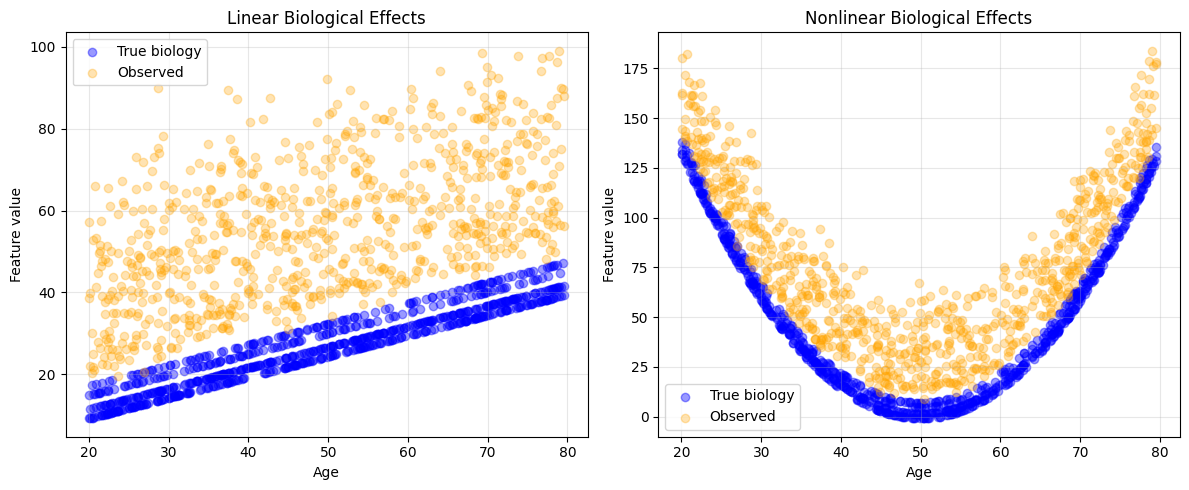

In [ ]:
# Visualize one feature - Linear vs Nonlinear
feature_idx = 0

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Linear plot
axes[0].scatter(
    age, Y_true_linear[feature_idx], alpha=0.4, label="True biology", color="blue"
)
axes[0].scatter(
    age, Y_obs_linear[feature_idx], alpha=0.3, label="Observed", color="orange"
)
axes[0].set_title("Linear Biological Effects")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Feature value")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Nonlinear plot
axes[1].scatter(
    age, Y_true_nonlinear[feature_idx], alpha=0.4, label="True biology", color="blue"
)
axes[1].scatter(
    age, Y_obs_nonlinear[feature_idx], alpha=0.3, label="Observed", color="orange"
)
axes[1].set_title("Nonlinear Biological Effects")
axes[1].set_xlabel("Age")
axes[1].set_ylabel("Feature value")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# ---------------------------
# Fit linear and quadratic models
# ---------------------------


def fit_models(age, y):
    # Linear
    X_lin = age.reshape(-1, 1)
    lin = LinearRegression().fit(X_lin, y)
    y_lin = lin.predict(X_lin)

    # Quadratic
    X_quad = np.column_stack([age, age**2])
    quad = LinearRegression().fit(X_quad, y)
    y_quad = quad.predict(X_quad)

    r2_lin = lin.score(X_lin, y)
    r2_quad = quad.score(X_quad, y)

    rmse_lin = np.sqrt(mean_squared_error(y, y_lin))
    rmse_quad = np.sqrt(mean_squared_error(y, y_quad))

    return r2_lin, r2_quad, rmse_lin, rmse_quad

$R^2$: (goodness of fit)
- Measures how much variance in Y is explained by age (and age²)
- High $R^2$ → structure is captured (shape)
- Low $R^2$ → model cannot explain pattern

$R^2$ is about structure, not absolute accuracy

RMSE (error magnitude)
- Measures distance to true values
- Sensitive to bias + scaling errors

RMSE is about accuracy, not just shape

In [33]:
results_linear = []
results_nonlinear = []

for j in range(n_features):
    results_linear.append(fit_models(age, Y_true_linear[j]))
    results_nonlinear.append(fit_models(age, Y_true_nonlinear[j]))

results_linear = np.array(results_linear)
results_nonlinear = np.array(results_nonlinear)

print("=== LINEAR DATA ===")
print(f"R2 linear: \t {results_linear[:, 0].mean():0.5f}")
print(f"R2 quadratic:\t {results_linear[:, 1].mean():0.5f}")
print(f"RMSE linear:\t {results_linear[:, 2].mean():0.5f}")
print(f"RMSE quadratic:  {results_linear[:, 3].mean():0.5f}")

print("\n=== NONLINEAR DATA ===")
print(f"R2 linear:  \t {results_nonlinear[:, 0].mean():0.5f}")
print(f"R2 quadratic: \t {results_nonlinear[:, 1].mean():0.5f}")
print(f"RMSE linear:  \t {results_nonlinear[:, 2].mean():0.5f}")
print(f"RMSE quadratic:  {results_nonlinear[:, 3].mean():0.5f}")

=== LINEAR DATA ===
R2 linear: 	 0.91893
R2 quadratic:	 0.91919
RMSE linear:	 2.61830
RMSE quadratic:  2.61422

=== NONLINEAR DATA ===
R2 linear:  	 0.00224
R2 quadratic: 	 0.99368
RMSE linear:  	 35.53783
RMSE quadratic:  2.61422


### Final Interpretation

When the true biological relationship is linear, both linear and quadratic models provide an equivalent fit (R² ≈ 0.91, RMSE ≈ 2.6), indicating that a linear specification is sufficient to capture the underlying signal.

In contrast, when the true relationship is nonlinear, the linear model fails to explain the data (R² ≈ 0.003) and yields very large errors (RMSE ≈ 43), while the quadratic model achieves near-perfect fit (R² ≈ 0.996, RMSE ≈ 2.6). This demonstrates that linear models are fundamentally incapable of capturing nonlinear biological effects.

These results highlight that **model specification plays a critical role in accurately representing biological variation**. When the true relationship is nonlinear, using a linear model leads to severe mischaracterization of the signal, both in terms of explained variance and prediction accuracy.


## Step 2 — False positive rate (FPR) inflation under confounding

In real datasets scanner/site is often **correlated with biological variables**, e.g. different hospitals recruit different populations but ComBat, and L/S models generally, assumes that scanner effects are independent of biological effects.


We simulate a setting where:
- scanner and biology are correlated
- there is **no true group effect**

We then test whether ComBat introduces false positives. To obtain a reliable estimate of the false positive rate, we repeat the entire simulation multiple times with different random seeds.


In [ ]:
# Run multiple simulations to assess FPR and correlations
def run_fpr_simulation(seed, n=800, n_features=20):

    np.random.seed(seed)

    # Scanner
    scanner = np.random.choice(["A", "B", "C"], size=n)
    scanner_map = {"A": 0, "B": 1, "C": 2}
    scanner_num = np.array([scanner_map[s] for s in scanner])

    # correlated age
    age = np.zeros(n)
    for i, s in enumerate(scanner):
        if s == "A":
            age[i] = np.random.normal(30, 5)
        elif s == "B":
            age[i] = np.random.normal(50, 5)
        else:
            age[i] = np.random.normal(70, 5)

    sex = np.random.binomial(1, 0.5, n)
    disease = np.random.binomial(1, 0.3, n)

    Y_obs = []
    Y_true = []

    # Simulate observed features with scanner effects and interactions
    for j in range(n_features):
        scanner_effect = scanner_num * np.random.uniform(1.5, 3)
        interaction = scanner_num * 0.15 * age
        noise = np.random.normal(0, 2, n)

        # TRUE BIO: all linear effects + interaction
        true_bio = 0.05 * (age - 50) + 2 * sex + 5 * disease + 0.03 * age * disease

        y_j = true_bio + scanner_effect + interaction + noise
        Y_obs.append(y_j)
        Y_true.append(true_bio)

    Y_obs = np.array(Y_obs)
    Y_true = np.array(Y_true)

    # null group
    group = np.random.binomial(1, 0.5, n)

    covars = pd.DataFrame(
        {"batch": scanner, "age": age, "sex": sex, "group": group, "disease": disease}
    )

    combat_result = neuroCombat(
        dat=Y_obs,
        covars=covars,
        batch_col="batch",
        continuous_cols=["age"],
        categorical_cols=["sex", "disease", "group"],
    )

    Y_combat = combat_result["data"]

    # -----------------------------
    # P-values
    # -----------------------------
    pvals = []

    for j in range(n_features):
        p = ttest_ind(Y_combat[j][group == 0], Y_combat[j][group == 1]).pvalue
        pvals.append(p)

    pvals = np.array(pvals)

    # -----------------------------
    # Correlations (KEY ADDITION)
    # -----------------------------
    corr_scanner_age = np.corrcoef(scanner_num, age)[0, 1]
    corr_scanner_group = np.corrcoef(scanner_num, group)[0, 1]

    return pvals, corr_scanner_age, corr_scanner_group

In [ ]:
# Simulation parameters
n_runs = 1000
n_features = 10

pvals_matrix = np.zeros((n_features, n_runs))

corr_age_list = []
corr_group_list = []

# Run simulations
for i in range(n_runs):
    pvals, c_age, c_group = run_fpr_simulation(seed=i, n_features=n_features)

    pvals_matrix[:, i] = pvals

    corr_age_list.append(c_age)
    corr_group_list.append(c_group)

[neuroCombat] Creating design matrix
[neuroCombat] Standardizing data across features
[neuroCombat] Fitting L/S model and finding priors
[neuroCombat] Finding parametric adjustments
[neuroCombat] Final adjustment of data
[neuroCombat] Creating design matrix
[neuroCombat] Standardizing data across features
[neuroCombat] Fitting L/S model and finding priors
[neuroCombat] Finding parametric adjustments
[neuroCombat] Final adjustment of data
[neuroCombat] Creating design matrix
[neuroCombat] Standardizing data across features
[neuroCombat] Fitting L/S model and finding priors
[neuroCombat] Finding parametric adjustments
[neuroCombat] Final adjustment of data
[neuroCombat] Creating design matrix
[neuroCombat] Standardizing data across features
[neuroCombat] Fitting L/S model and finding priors
[neuroCombat] Finding parametric adjustments
[neuroCombat] Final adjustment of data
[neuroCombat] Creating design matrix
[neuroCombat] Standardizing data across features
[neuroCombat] Fitting L/S mode

In [36]:
print(f"Mean correlation scanner-age:\t{np.mean(corr_age_list):0.5f}")
print(f"Mean correlation scanner-group:\t{np.mean(corr_group_list):0.5f}")

alpha = 0.05

fpr_per_feature = np.mean(pvals_matrix < alpha, axis=1)

print("FPR per feature:", fpr_per_feature)

Mean correlation scanner-age:	0.95619
Mean correlation scanner-group:	0.00069
FPR per feature: [0.059 0.058 0.059 0.057 0.072 0.065 0.059 0.064 0.063 0.059]


When interpreting the observed False Positive Rate (FPR) in our simulation experiments, it is important to account for the variability that arises from the finite number of simulation replicates. Under the null hypothesis, the number of spurious group effects detected across $N$ simulations follows a binomial distribution with probability $p = 0.05$. Even if a method is well-calibrated, we do not expect the observed FPR to be exactly $0.05$ in every experiment due to random variation. To determine whether an observed FPR is meaningfully higher than expected, we compute an upper confidence bound for $\hat{p}$, the sample estimate of the FPR, using a normal approximation to the binomial:
$$ \hat{p} \pm 1.645 \times \sqrt{\frac{\hat{p}(1-\hat{p})}{N}}$$
This expression gives the 95th percentile (one-sided) of the sampling distribution of the FPR under the null. 


In [38]:
alpha = 0.05  # nominal FPR
N = 1000  # number of simulations (or tests)

# standard deviation under binomial
std = np.sqrt(alpha * (1 - alpha) / N)

# one-sided 95% bound (z = 1.645)
lower = alpha - 1.645 * std
upper = alpha + 1.645 * std

print("Expected FPR:", alpha)
print(
    f"95% confidence interval for FPR under null: {lower:0.5f}, {upper:0.5f}",
)


Expected FPR: 0.05
95% confidence interval for FPR under null: 0.03866, 0.06134


Substituting $\hat{p}=0.05$ and $N=1000$, we get an upper bound of approximately 0.06 and lower bound of 0.04. In other words, even a well-calibrated method can yield an observed FPR as high as 6\% or as low as 4\% just by chance. However, if the FPR exceeds the upper bound, it suggests the method is truly inflating Type I error, not just experiencing random fluctuation. Instead, an FPR below 4\% indicates that the method is overly conservative, potentially sacrificing power to avoid false positives. Thus, in our simulation studies, FPRs above 0.06 are interpreted as significant inflation, while values below 0.04 signal excessive conservatism.

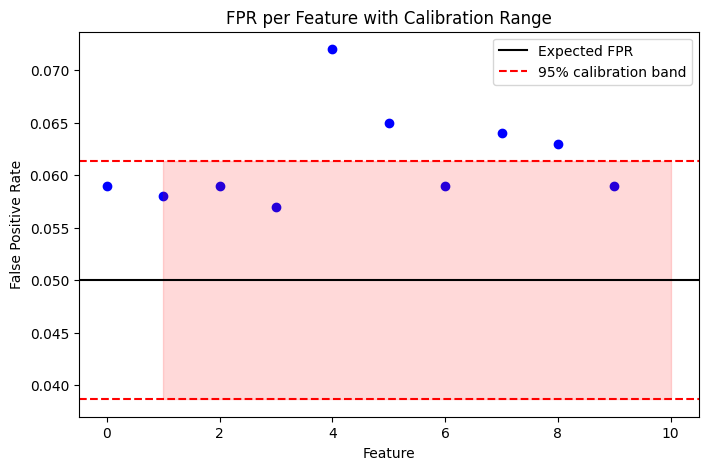

In [ ]:
# x-axis: feature index
x = np.arange(len(fpr_per_feature))

plt.figure(figsize=(8, 5))

# scatter: one dot per feature
plt.scatter(x, fpr_per_feature, color="blue")

# expected FPR
plt.axhline(alpha, color="black", label="Expected FPR")

# calibration band
plt.axhline(lower, color="red", linestyle="--", label="95% calibration band")
plt.axhline(upper, color="red", linestyle="--")

# optional: shade region (nicer)
plt.fill_between(x, lower, upper, color="red", alpha=0.15)

plt.xlabel("Feature")
plt.ylabel("False Positive Rate")
plt.title("FPR per Feature with Calibration Range")

plt.legend()
plt.show()

ComBat leads to FPR values that are systematically above the nominal level (0.05) and for several features exceed the 95% calibration band, indicating **inflated false positive rates** . 

####  Key takeaway

Even when ComBat reduces apparent scanner effects, it does not ensure valid statistical inference.  
In particular, it can lead to **inflated false positive rates**, highlighting a limitation of location–scale harmonization methods under realistic data conditions.


## Step 3 — Limitations of Discrete Scanner Modeling

ComBat and, as far as this author's knowledge goes, all other harmonization approaches model scanner effects using **discrete scanner identifiers**. However, in real neuroimaging data:
- scanner-related variability is often **continuous**
  - e.g. signal-to-noise ratio (SNR)
  - contrast-to-noise ratio (CNR)
  - acquisition drift
- and varies **within scanner** as well.


#### Simulation design

We generate:
- discrete scanner IDs (A, B, C)
- a continuous latent variable representing scanner quality

The true scanner effect depends on this continuous variable, not just the scanner label.

In [ ]:
# Simulation parameters
n = 800
n_features = 20

# scanner IDs
scanner = np.random.choice(["A", "B", "C"], size=n)
scanner_map = {"A": 0, "B": 1, "C": 2}
scanner_num = np.array([scanner_map[s] for s in scanner])

# continuous scanner variation (IQM-like)
scanner_quality = (
    scanner_num + np.random.normal(0, 0.8, n)  # large within-scanner variation
)

age = np.random.uniform(20, 80, n)
sex = np.random.binomial(1, 0.5, n)
disease = np.random.binomial(1, 0.3, n)

Y_obs = []
Y_true = []

for j in range(n_features):
    # TRUE BIO: all linear effects + interaction
    true_bio = (
        0.05 * (age - 50)
        + abs(np.random.uniform(1.5, 2.5)) * sex
        + 5 * disease
        + 0.03 * age * disease
    )

    base_scanner_effect = scanner_num * abs(np.random.uniform(1.5, 3))

    # IMPORTANT: scanner effect depends on continuous variable
    continuous_scanner_effect = 3 * scanner_quality  # NOT discrete

    # small noise
    noise = np.random.normal(0, 2, n)

    y_j = true_bio + continuous_scanner_effect + base_scanner_effect + noise
    Y_obs.append(y_j)
    Y_true.append(true_bio)

Y_obs = np.array(Y_obs)
Y_true = np.array(Y_true)

### Apply ComBat

In [ ]:
covars = pd.DataFrame({"batch": scanner, "age": age, "disease": disease, "sex": sex})

combat_result = neuroCombat(
    dat=Y_obs,
    covars=covars,
    batch_col="batch",
    continuous_cols=["age"],
    categorical_cols=["sex", "disease"],
)

Y_combat = combat_result["data"]

[neuroCombat] Creating design matrix
[neuroCombat] Standardizing data across features
[neuroCombat] Fitting L/S model and finding priors
[neuroCombat] Finding parametric adjustments
[neuroCombat] Final adjustment of data


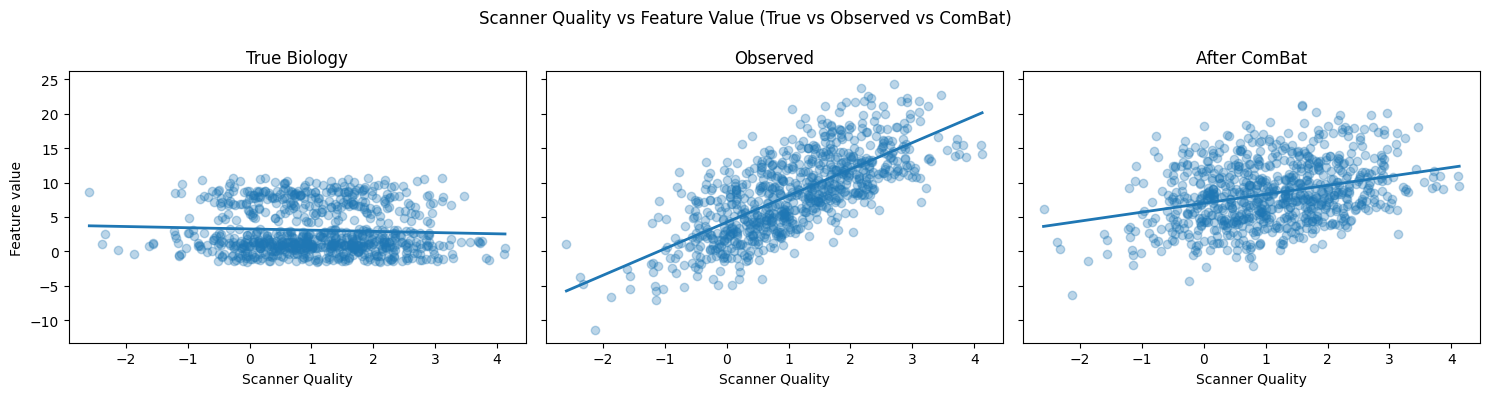

In [ ]:
j = 0  # feature index

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

titles = ["True Biology", "Observed", "After ComBat"]
data_list = [Y_true[j], Y_obs[j], Y_combat[j]]

for ax, data, title in zip(axes, data_list, titles):
    # Scatter
    ax.scatter(scanner_quality, data, alpha=0.3)

    # Fit line
    coef = np.polyfit(scanner_quality, data, 1)
    x_line = np.linspace(scanner_quality.min(), scanner_quality.max(), 100)
    y_line = coef[0] * x_line + coef[1]

    ax.plot(x_line, y_line, linewidth=2)

    ax.set_title(title)
    ax.set_xlabel("Scanner Quality")

axes[0].set_ylabel("Feature value")

plt.suptitle("Scanner Quality vs Feature Value (True vs Observed vs ComBat)")
plt.tight_layout()
plt.show()

In [47]:
corr_residual = np.corrcoef(scanner_quality, Y_combat[j])[0, 1]
corr_raw = np.corrcoef(scanner_quality, Y_obs[j])[0, 1]
corr_bio = np.corrcoef(scanner_quality, Y_true[j])[0, 1]

print(f"Biological correlation:\t{corr_bio:0.5f}")
print(f"Raw observed correlation:{corr_raw:0.5f}")
print(f"After ComBat:\t\t {corr_residual:0.5f}", )

Biological correlation:	-0.05599
Raw observed correlation:0.71508
After ComBat:		 0.31461


ComBat:
- reduces the association between scanner quality and the observed data  
- partially removes scanner-related variability  
- decreases the correlation from ~0.7 (raw) to ~0.3

BUT:

- a clear residual relationship remains between scanner quality and the corrected data  
- the fitted trend and non-zero correlation indicate **incomplete removal of scanner effects**  
- this residual dependence is not present in the true biological signal (~0), confirming it is an artifact  


### Key takeaway

ComBat reduces scanner-induced variability but does not fully eliminate it.  
Residual associations with continuous scanner-related factors remain, highlighting a limitation of discrete location–scale harmonization methods when scanner variation is continuous.

### Solution

You can check the solutions of this notebook [here](https://github.com/N-Nieto/OHBM2026_Educational_course_harmonization/tree/main/solutions/block03)